# LeetCode #99: Recover Binary Search Tree

https://leetcode.com/problems/recover-binary-search-tree/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Collect inorder, sort, overwrite | O(n log n) | O(n) | Get inorder values, sort, write back |
| **DFS Inorder (find violations) ★** | **O(n)** | **O(n)** | Track prev; first violation sets `first`, every violation updates `second` |
| Morris Traversal | O(n) | O(1) | Same logic; threaded links for O(1) space |

---

## Understanding the Methods

### Brute Force (Sort)
Collect inorder values, sort them, overwrite node values in inorder order. O(n log n).

### Optimal: DFS Inorder ★
BST inorder traversal should be strictly sorted. A single swap creates either:
- 1 violation (adjacent nodes swapped): [1, 3, 2, 4] → `first=3, second=2`
- 2 violations (non-adjacent): [1, 6, 3, 4, 5, 2] → `first=6` (1st violation's prev), `second=2` (last violation's curr)

Algorithm: track `prev` node during inorder. When prev.val > curr.val: set first=prev (only first time), always set second=curr. After traversal, swap first.val and second.val.

**Constraints:**
* Number of nodes: [2, 1000]
* Node values: [-2^31, 2^31 - 1]
* Exactly two nodes are swapped

## Solutions

### C#

In [ ]:
public class Solution {
    TreeNode first = null, second = null, prev = null;

    public void RecoverTree(TreeNode root) {
        Inorder(root);
        (first.val, second.val) = (second.val, first.val);
    }

    void Inorder(TreeNode node) {
        if (node == null) return;
        Inorder(node.left);
        if (prev != null && prev.val > node.val) {
            if (first == null) first = prev; // first violation: misplaced bigger node
            second = node;                    // keep updating: misplaced smaller node
        }
        prev = node;
        Inorder(node.right);
    }
}

### Python

In [ ]:
class Solution:
    def recoverTree(self, root) -> None:
        self.first = self.second = self.prev = None

        def inorder(node):
            if not node:
                return
            inorder(node.left)
            if self.prev and self.prev.val > node.val:
                if not self.first:
                    self.first = self.prev
                self.second = node
            self.prev = node
            inorder(node.right)

        inorder(root)
        self.first.val, self.second.val = self.second.val, self.first.val

### Go

In [ ]:
var first, second, prev *TreeNode

func recoverTree(root *TreeNode) {
    first, second, prev = nil, nil, nil
    inorder(root)
    first.Val, second.Val = second.Val, first.Val
}

func inorder(node *TreeNode) {
    if node == nil {
        return
    }
    inorder(node.Left)
    if prev != nil && prev.Val > node.Val {
        if first == nil {
            first = prev
        }
        second = node
    }
    prev = node
    inorder(node.Right)
}

### Rust

In [ ]:
impl Solution {
    pub fn recover_tree(root: &mut Option<Rc<RefCell<TreeNode>>>) {
        let mut first: Option<Rc<RefCell<TreeNode>>> = None;
        let mut second: Option<Rc<RefCell<TreeNode>>> = None;
        let mut prev: Option<Rc<RefCell<TreeNode>>> = None;

        // Collect inorder values and node refs
        let mut nodes: Vec<Rc<RefCell<TreeNode>>> = Vec::new();
        Self::collect(root, &mut nodes);

        for i in 1..nodes.len() {
            let a = nodes[i-1].borrow().val;
            let b = nodes[i].borrow().val;
            if a > b {
                if first.is_none() { first = Some(nodes[i-1].clone()); }
                second = Some(nodes[i].clone());
            }
        }

        if let (Some(f), Some(s)) = (first, second) {
            let fv = f.borrow().val;
            let sv = s.borrow().val;
            f.borrow_mut().val = sv;
            s.borrow_mut().val = fv;
        }
    }

    fn collect(node: &Option<Rc<RefCell<TreeNode>>>, nodes: &mut Vec<Rc<RefCell<TreeNode>>>) {
        if let Some(n) = node {
            Self::collect(&n.borrow().left.clone(), nodes);
            nodes.push(n.clone());
            Self::collect(&n.borrow().right.clone(), nodes);
        }
    }
}

## Example Scenarios

### 1. Common Case — Non-Adjacent Swap
**Input:** `root = [1, 3, null, null, 2]` (nodes 3 and 2 are swapped)

Correct BST: [1,2,null,null,3]. Inorder of corrupted tree: [3,2,1]. First violation: prev=3 > curr=2 → first=3, second=2. Second violation: prev=2 > curr=1 → second updated to 1. Swap first(3) and second(1).

*Why tricky:* Two violations means non-adjacent swap. The algorithm sets first on the 1st violation and keeps updating second on every subsequent violation.

Inorder: $[3, 2, 1]$. Violations at indices $(0,1)$ and $(1,2)$. first $= 3$, second $= 1$.

**Output:** Swap $3 \leftrightarrow 1$ → corrected BST `[1, 2, null, null, 3]`

---

### 2. Slightly Complex — Adjacent Swap in Larger Tree
**Input:** `root = [6, 5, 8, 1, 3, 7, 9]` (nodes 3 and 5 swapped from correct `[6,3,8,1,5,7,9]`)

Inorder: [1, 5, 3, 6, 7, 8, 9]. One violation: prev=5 > curr=3 → first=5, second=3. Adjacent swap produces exactly one violation.

*Why tricky:* Adjacent swap creates only 1 violation. Tests that the algorithm correctly identifies both first and second from a single violation event.

Inorder: $[1, \mathbf{5}, \mathbf{3}, 6, 7, 8, 9]$. One violation. first $= 5$, second $= 3$.

**Output:** Swap $5 \leftrightarrow 3$ → corrected BST

---

### 3. Edge Case: Time Factor — 1000 Nodes, Swap at Extremes
**Input:** BST with nodes $1 \ldots 1000$, nodes 1 and 1000 swapped

Inorder: $[1000, 2, 3, \ldots, 999, 1]$. First violation at start: prev=1000 > curr=2. Last violation at end: prev=999 > curr=1. Full traversal required — cannot short-circuit.

*Why tricky:* Maximum $n = 1000$ with swapped nodes at extreme positions. Must traverse all nodes to find the second violation at the end.

$n = 1000$. Two violations at indices $(0,1)$ and $(998,999)$. Full $O(n)$ traversal.

**Output:** Swap $1000 \leftrightarrow 1$ → corrected BST

---

### 4. Edge Case: Space Factor — Two-Node Tree
**Input:** `root = [1, 2]` (correct should be `[2, 1]`)

Inorder: [2, 1]. One violation: prev=2 > curr=1 → first=2, second=1. Swap restores valid BST. Minimum tree size with minimum recursion depth.

*Why tricky:* Minimum possible tree ($n = 2$, per constraint). Only 1 recursion level. Tests that the algorithm handles the smallest valid input.

$n = 2$. Stack depth $= 2$. One violation detected.

**Output:** Swap $1 \leftrightarrow 2$ → corrected BST `[2, 1]`

---

### 5. Almost-Impossible but Plausible — INT_MIN and INT_MAX Swapped
**Input:** BST with values including $-2^{31}$ and $2^{31}-1$, these two nodes swapped

Inorder starts with $2^{31}-1$ (was min position) and ends with $-2^{31}$ (was max position). Two violations at the extremes of the traversal.

*Why tricky:* 32-bit extreme values test for overflow in comparisons. Difference $= 2^{32}-1 \approx 4.3 \times 10^9$. Languages with signed overflow could corrupt the comparison.

first $= 2{,}147{,}483{,}647$, second $= -2{,}147{,}483{,}648$.

**Output:** Swap INT_MAX $\leftrightarrow$ INT_MIN → corrected BST

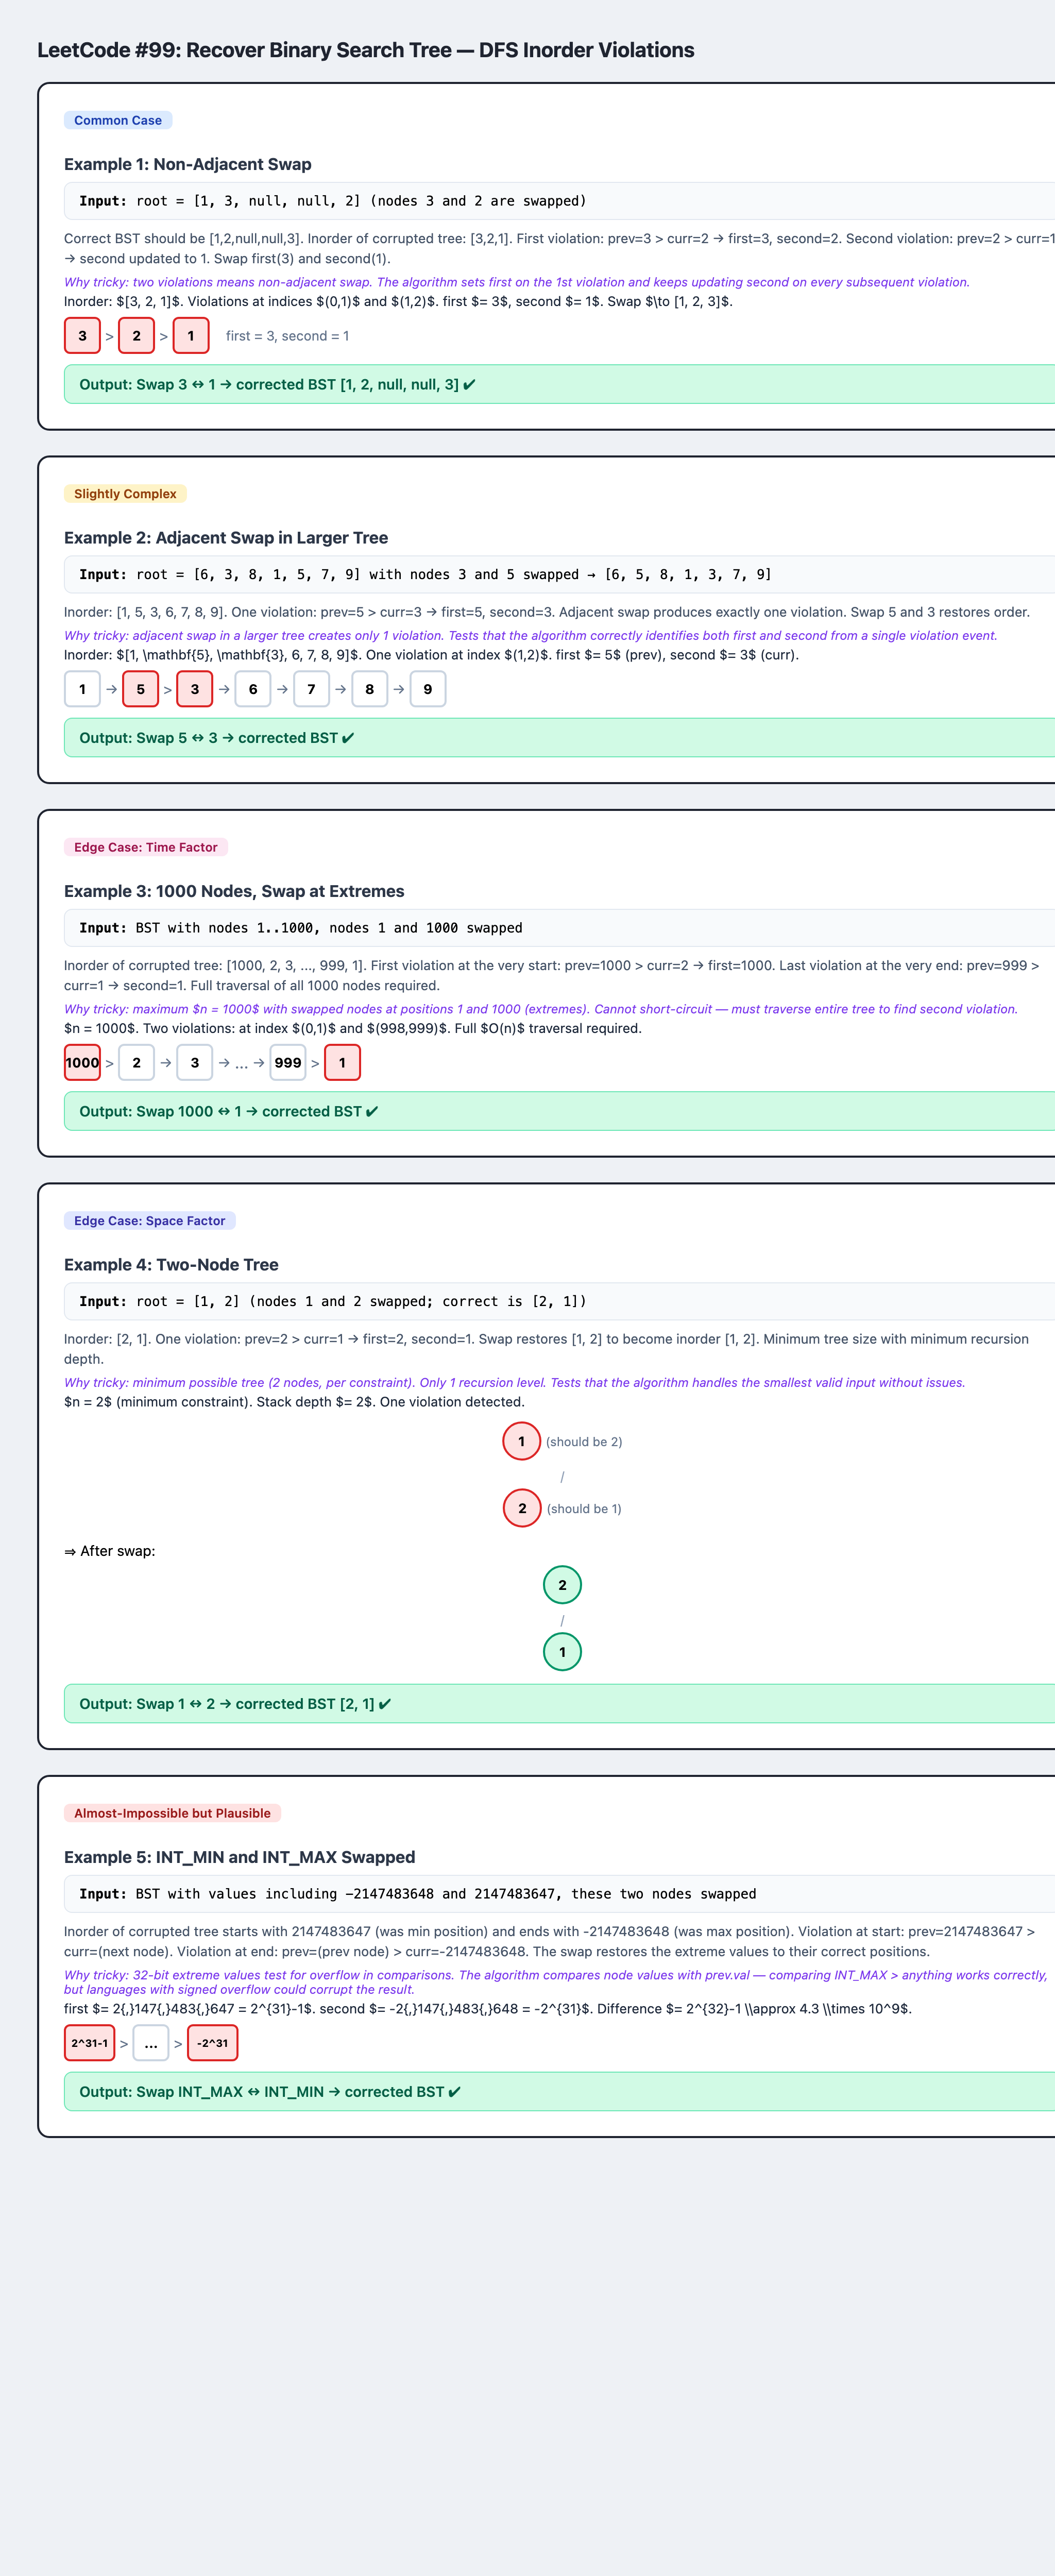